Création des fenêtres...
Tailles des jeux : Train=147731 | Val=42204 | Test=21104

--- ENTRAÎNEMENT CAE ---
Epoch 1/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - loss: 0.1001 - val_loss: 0.0631
Epoch 2/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - loss: 0.0545 - val_loss: 0.0586
Epoch 3/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - loss: 0.0496 - val_loss: 0.0516
Epoch 4/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - loss: 0.0481 - val_loss: 0.0539
Epoch 5/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - loss: 0.0473 - val_loss: 0.0502
Epoch 6/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - loss: 0.0461 - val_loss: 0.0754
Epoch 7/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - loss: 0.0459 - val_loss: 0.0478
Epoch 8/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - loss: 0.0446 - val_loss: 0.0474
Epoch 9/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - loss: 0.0440 - val_loss: 0.0464
Epoch 10/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - loss: 0.0433 - val_loss: 0.0447
E

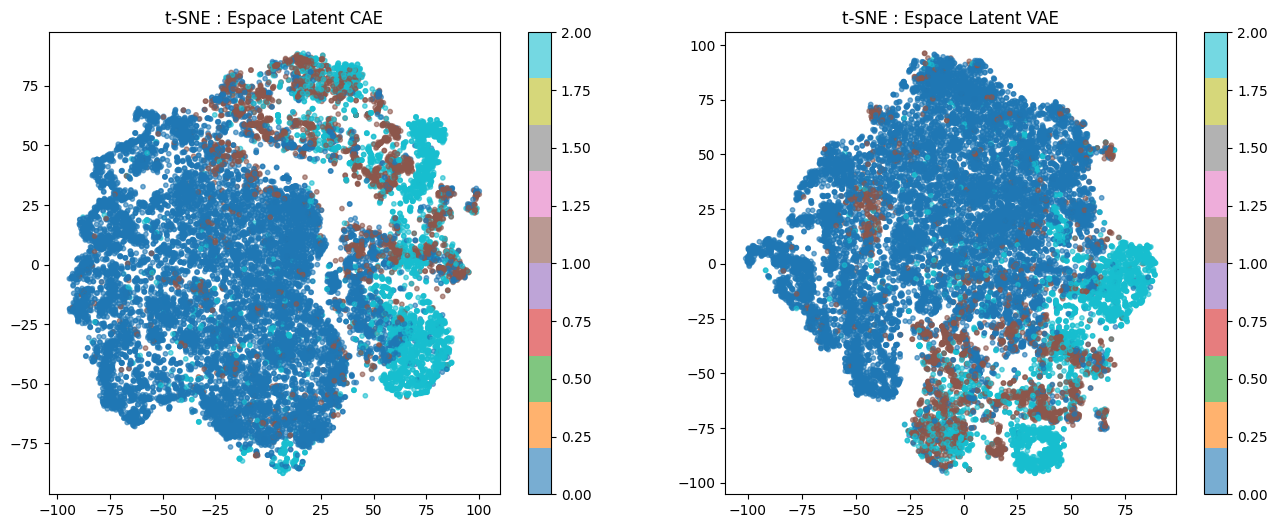

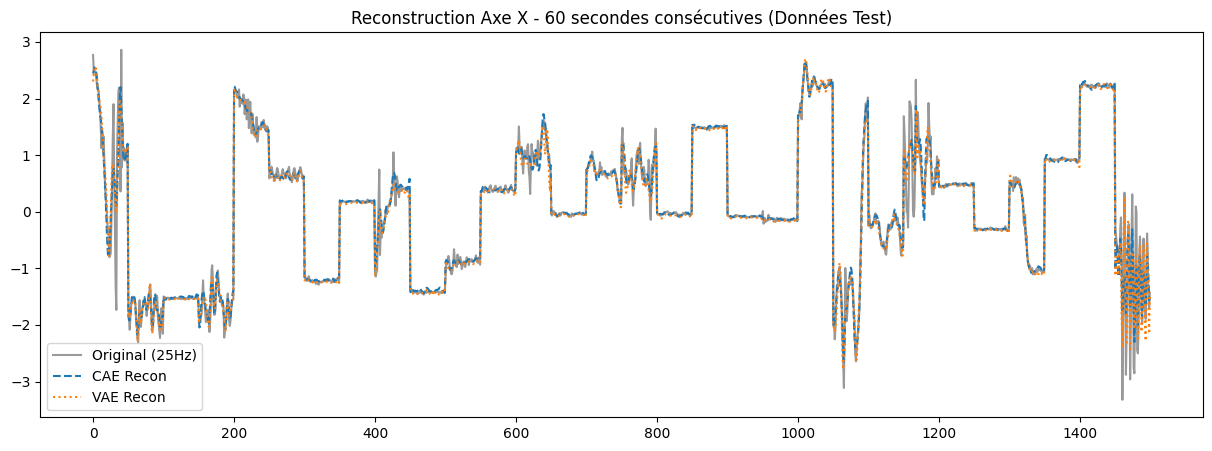

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import time

# =========================================================
# 1. PRÉPARATION COMMUNE ET SPLIT 70/20/10
# =========================================================
path = "C:/Users/Théo Lassale/Desktop/Perso/Stage/Stage_Malmö/IMU_LM_Data/data/merged_dataset/filtered_activities_dataset.parquet"
df = pd.read_parquet(path)

# Uniquement Accéléromètre 3D
features = ["acc_x", "acc_y", "acc_z"]
df = df[["timestamp_ns", "dataset", "subject_id", "session_id", "global_activity_id"] + features]

# Passage à 25Hz (1 ligne sur 2)
df = df.iloc[::2].copy()

# Nettoyage
df[features] = df[features].interpolate(method='linear').bfill().ffill()

# Fenêtrage (2 secondes = 50 points)
WINDOW_SIZE, STRIDE = 50, 25
X, labels = [], []

print("Création des fenêtres...")
for _, group in df.groupby(["dataset", "subject_id", "session_id"]):
    sig = group[features].values
    acts = group["global_activity_id"].values
    for i in range(0, len(sig) - WINDOW_SIZE, STRIDE):
        X.append(sig[i:i + WINDOW_SIZE])
        labels.append(np.bincount(acts[i:i + WINDOW_SIZE]).argmax())

X = np.array(X, dtype=np.float32)
labels = np.array(labels)

# Normalisation globale
X_mean, X_std = np.mean(X, axis=(0, 1)), np.std(X, axis=(0, 1))
X = (X - X_mean) / (X_std + 1e-7)

# --- SPLIT STRICT 70/20/10 ---
# 1. On sépare les 10% de test final
X_temp, X_test, y_temp, y_test = train_test_split(X, labels, test_size=0.10, random_state=42)

# 2. Dans les 90% restants, on prend 22.22% pour la validation (ce qui fait 20% du total initial car 0.22*0.9 ≈ 0.20)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2222, random_state=42)

print(f"Tailles des jeux : Train={len(X_train)} | Val={len(X_val)} | Test={len(X_test)}")

# Hyperparamètres
timesteps, n_features = 50, 3
latent_dim = 32
EPOCHS = 150
BATCH_SIZE = 256
PATIENCE = 8

# =========================================================
# 2. ARCHITECTURE LOGIQUE (32 -> 64 -> 128)
# =========================================================

def get_encoder_cae():
    inputs = layers.Input(shape=(timesteps, n_features))
    x = layers.Conv1D(32, 5, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2)(x) # 25
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x) # 12
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    latent = layers.Dense(latent_dim, name="cae_latent")(x)
    return Model(inputs, latent, name="Encoder_CAE")

def get_encoder_vae():
    inputs = layers.Input(shape=(timesteps, n_features))
    x = layers.Conv1D(32, 5, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    return Model(inputs, [z_mean, z_log_var], name="Encoder_VAE")

def get_decoder(name):
    inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(12 * 128, activation='relu')(inputs)
    x = layers.Reshape((12, 128))(x)
    x = layers.UpSampling1D(2)(x) # 24
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x) # 48
    x = layers.ZeroPadding1D(padding=(1, 1))(x) # Ajustement à 50
    x = layers.Conv1D(32, 5, activation='relu', padding='same')(x)
    outputs = layers.Conv1D(n_features, 5, activation='linear', padding='same')(x)
    return Model(inputs, outputs, name=name)

# =========================================================
# 3. BLOC CAE (Indépendant)
# =========================================================
print("\n--- ENTRAÎNEMENT CAE ---")
cae_encoder = get_encoder_cae()
cae_decoder = get_decoder("Decoder_CAE")
cae_model = Model(cae_encoder.input, cae_decoder(cae_encoder.output))

cae_model.compile(optimizer='adam', loss='mse')
t0 = time.time()
history_cae = cae_model.fit(
    X_train, X_train, 
    validation_data=(X_val, X_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)]
)
time_cae = time.time() - t0

# =========================================================
# 4. BLOC VAE (Indépendant)
# =========================================================
print("\n--- ENTRAÎNEMENT VAE ---")

class BetaVAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder, self.decoder = encoder, decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon")

    def train_step(self, data):
        with tf.GradientTape() as tape:
            zm, zv = self.encoder(data)
            # Sampling réduit pour le moment (0.1)
            z = zm + 0.1 * tf.exp(0.5 * zv) * tf.random.normal(tf.shape(zm))
            recon = self.decoder(z)
            r_loss = tf.reduce_mean(tf.reduce_sum(tf.keras.losses.mse(data, recon), axis=-1))
            kl_loss = -0.5 * tf.reduce_mean(1 + zv - tf.square(zm) - tf.exp(zv))
            total_loss = r_loss + 0.01 * kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(r_loss)
        return {"loss": self.total_loss_tracker.result(), "recon": self.recon_loss_tracker.result()}

vae_enc = get_encoder_vae()
vae_dec = get_decoder("Decoder_VAE")
vae_model = BetaVAE(vae_enc, vae_dec)
vae_model.compile(optimizer=tf.keras.optimizers.Adam())

t0 = time.time()
# Le VAE utilise X_val pour monitorer via un callback manuel ou juste la perte d'entraînement
history_vae = vae_model.fit(
    X_train, 
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='loss', patience=PATIENCE, restore_best_weights=True)]
)
time_vae = time.time() - t0

# =========================================================
# 5. SYNTHÈSE ET COMPARAISON (SUR LE TEST SET)
# =========================================================

# Évaluation CAE
mse_cae = cae_model.evaluate(X_test, X_test, verbose=0)

# Évaluation VAE
zm_test, _ = vae_enc.predict(X_test, verbose=0)
recon_vae = vae_dec.predict(zm_test, verbose=0)
mse_vae = np.mean(np.square(X_test - recon_vae))

print("\n" + "="*40)
print(f"COMPARAISON FINALE (Test Set : {len(X_test)} fenêtres)")
print("="*40)
print(f"CAE : Temps={time_cae:.1f}s | MSE={mse_cae:.6f}")
print(f"VAE : Temps={time_vae:.1f}s | MSE={mse_vae:.6f}")

# Visualisation t-SNE
print("\nCalcul t-SNE sur l'espace latent (Test Set)...")
lat_cae = cae_encoder.predict(X_test, verbose=0)
lat_vae, _ = vae_enc.predict(X_test, verbose=0)

tsne = TSNE(n_components=2, random_state=42)
emb_cae = tsne.fit_transform(lat_cae)
emb_vae = tsne.fit_transform(lat_vae)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sc1 = ax1.scatter(emb_cae[:, 0], emb_cae[:, 1], c=y_test, cmap='tab10', s=10, alpha=0.6)
ax1.set_title("t-SNE : Espace Latent CAE")
plt.colorbar(sc1, ax=ax1)

sc2 = ax2.scatter(emb_vae[:, 0], emb_vae[:, 1], c=y_test, cmap='tab10', s=10, alpha=0.6)
ax2.set_title("t-SNE : Espace Latent VAE")
plt.colorbar(sc2, ax=ax2)
plt.show()

# Comparaison Reconstruction sur 1 minute (30 fenêtres consécutives du test set)
plt.figure(figsize=(15, 5))
orig_plot = X_test[:30, :, 0].flatten() # Axe X
cae_plot = cae_model.predict(X_test[:30], verbose=0)[:, :, 0].flatten()
vae_plot = recon_vae[:30, :, 0].flatten()

plt.plot(orig_plot, label="Original (25Hz)", color='black', alpha=0.4)
plt.plot(cae_plot, label="CAE Recon", linestyle='--')
plt.plot(vae_plot, label="VAE Recon", linestyle=':')
plt.title("Reconstruction Axe X - 60 secondes consécutives (Données Test)")
plt.legend()
plt.show()